#  Классификация изображений с помощью сверточных нейронных сетей

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/nn.html#convolution-layers
* https://pytorch.org/vision/0.16/transforms.html#v2-api-reference-recommended
* https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
* https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html
* https://kozodoi.me/blog/20210308/compute-image-stats
* https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.matshow.html

## Задачи для совместного разбора

1\. Рассмотрите основные возможности по созданию датасетов из `torchvision` и примеры работы основных слоев для создания сверточных нейронных сетей для анализа изображений.

2\. Реализуйте типовую архитектуру CNN для классификации изображений.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте датасет `CatBreeds` на основе данных из архива `cat_breeds_4.zip`. Используя преобразования `torchvision`, приведите картинки к размеру 300х300 и нормализуйте значения интенсивности пикселей (рассчитайте статистику для нормализации отдельно). Выведите на экран количество картинок в датасете,  размер одной картинки, количество уникальных классов. Разбейте датасет на обучающее и тестовое множество в соотношении 80 на 20%.

- [ ] Проверено на семинаре

In [3]:
import os
import random
import zipfile
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(42)
random.seed(42)

extract_dir = os.path.join(os.getcwd(), "data")
zip_path = os.path.join(extract_dir, "cat_breeds_4.zip")
root_dir = os.path.join(extract_dir, "cat_breeds_4")

if not os.path.isdir(root_dir):
    with zipfile.ZipFile(zip_path) as zip_ref:
        zip_ref.extractall(extract_dir)

transform_for_stats = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root_dir, transform=transform_for_stats)
num_images = len(full_dataset)
num_classes = len(full_dataset.classes)
sample_img, _ = full_dataset[0]

loader_for_stats = DataLoader(full_dataset, batch_size=32, shuffle=False)
channel_sum = torch.zeros(3)
channel_sq_sum = torch.zeros(3)
num_pixels = 0

for images, _ in loader_for_stats:
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_sq_sum += (images ** 2).sum(dim=(0, 2, 3))
    num_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / num_pixels
std = torch.sqrt(channel_sq_sum / num_pixels - mean ** 2)

transform_final = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

full_dataset_normalized = datasets.ImageFolder(root_dir, transform=transform_final)

train_ratio = 0.8
train_size = int(train_ratio * num_images)
test_size = num_images - train_size
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(num_images, generator=generator).tolist()
train_indices = indices[:train_size]
test_indices = indices[train_size:]
train_dataset = Subset(full_dataset_normalized, train_indices)
test_dataset = Subset(full_dataset_normalized, test_indices)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            logits = model(images)
            predictions = logits.argmax(dim=1)
            correct += (predictions == targets).sum().item()
            total += targets.size(0)
    return correct / total

def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "train_acc": [], "test_acc": []}

    for _ in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * targets.size(0)
            predictions = logits.argmax(dim=1)
            correct += (predictions == targets).sum().item()
            total += targets.size(0)

        history["loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)
        history["test_acc"].append(evaluate_accuracy(model, test_loader))

    return history

def get_class_names(dataset):
    return dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes

def denormalize(image):
    return image * std.view(-1, 1, 1) + mean.view(-1, 1, 1)

print(f"images: {num_images}")
print(f"image size: {sample_img.shape}")
print(f"classes: {num_classes}")


images: 4000
image size: torch.Size([3, 300, 300])
classes: 4


<p class="task" id="2"></p>

2\. Решите задачу классификации на основе датасета из предыдущего задания, не используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели.   

- [ ] Проверено на семинаре

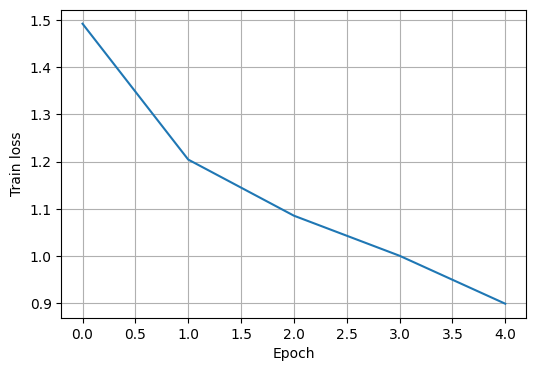

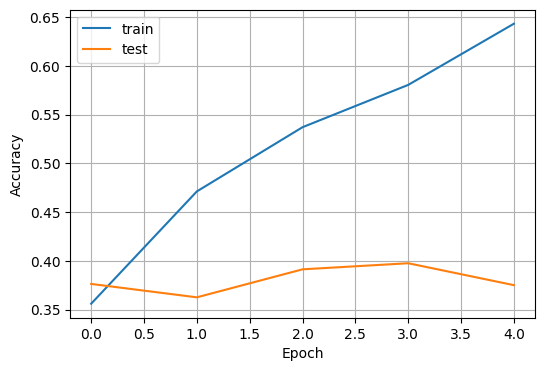

train accuracy: 0.6434
test accuracy: 0.3750
parameters: 393860


In [4]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

class MLPClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d((32, 32)),
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

mlp_model = MLPClassifier(num_classes).to(device)
history = train_model(mlp_model, train_loader, test_loader, epochs=5)

plt.figure(figsize=(6, 4))
plt.plot(history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history["train_acc"], label="train")
plt.plot(history["test_acc"], label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print(f"train accuracy: {history['train_acc'][-1]:.4f}")
print(f"test accuracy: {history['test_acc'][-1]:.4f}")
print(f"parameters: {sum(p.numel() for p in mlp_model.parameters())}")


<p class="task" id="3"></p>

3\. Напишите функцию, которая выбирает несколько изображений из переданного набора данных и выводит их на экран в виде сетки с указанием над ними названия правильного класса и класса, предсказанного моделью. Воспользовавшись данной функцией, выведите прогнозы итоговой модели из предыдущей задачи по 6 случайным картинкам.

```
def show_examples(model, dataset, k=6):
    pass
```

- [ ] Проверено на семинаре

In [5]:
def show_examples(model, dataset, k=6):
    model.eval()
    class_names = get_class_names(dataset)
    indices = torch.randperm(len(dataset))[:k].tolist()
    fig, axes = plt.subplots(1, k, figsize=(3 * k, 4))
    if k == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image, target = dataset[idx]
            prediction = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()
            image = denormalize(image).clamp(0, 1).cpu()
            ax.imshow(image.permute(1, 2, 0))
            ax.set_title(f"true: {class_names[target]}\npred: {class_names[prediction]}")
            ax.axis("off")

    plt.tight_layout()
    plt.show()


<p class="task" id="4"></p>

4\. Решите задачу классификации на основе датасета из первого задания, используя сверточные слои. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики accuracy на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран итоговое значение метрики accuracy на обучающем и тестовом множестве. Выведите на экран количество параметров модели. Воспользовавшись функцией из предыдущего задания, выведите прогнозы итоговой модели по 6 случайным картинкам.

- [ ] Проверено на семинаре

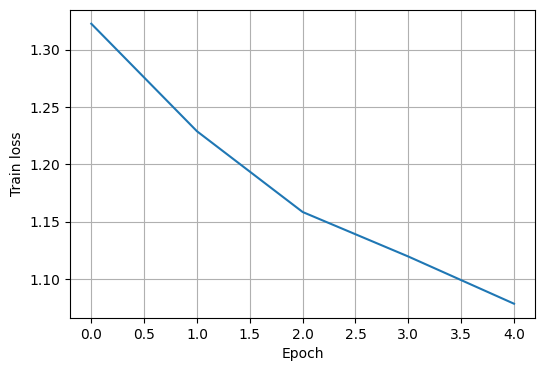

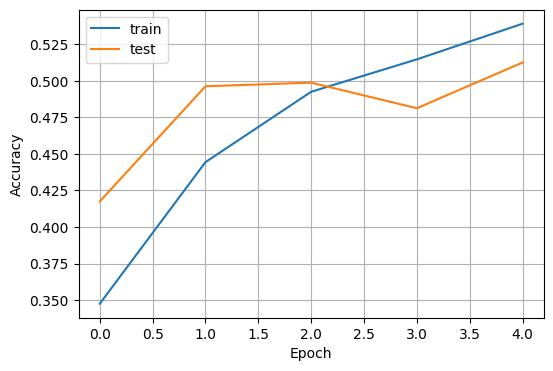

train accuracy: 0.5391
test accuracy: 0.5125
parameters: 548516


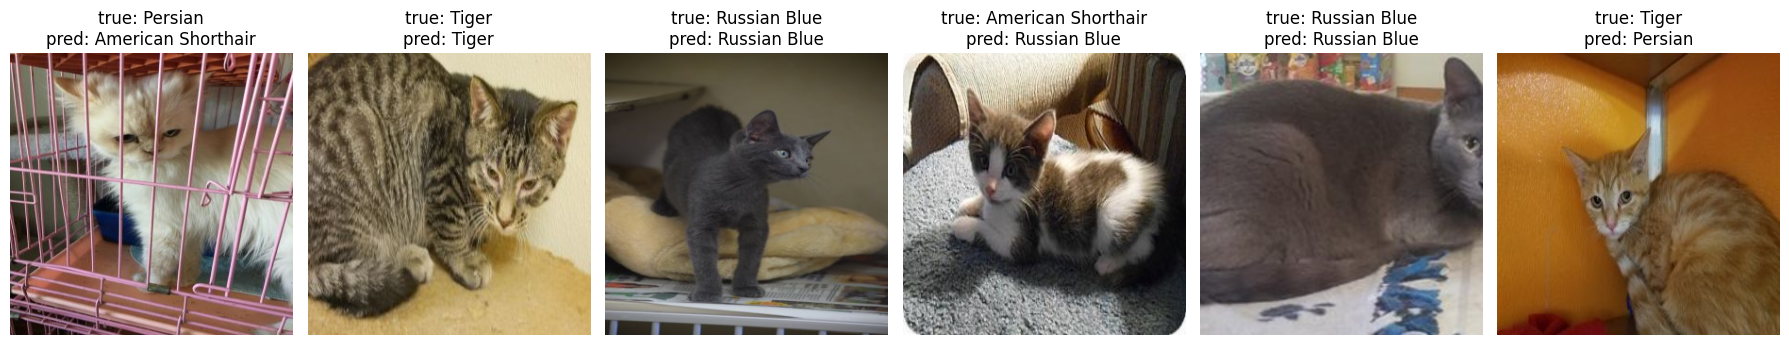

In [6]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((8, 8)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

cnn_model = CNNClassifier(num_classes).to(device)
cnn_history = train_model(cnn_model, train_loader, test_loader, epochs=5)

plt.figure(figsize=(6, 4))
plt.plot(cnn_history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(cnn_history["train_acc"], label="train")
plt.plot(cnn_history["test_acc"], label="test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print(f"train accuracy: {cnn_history['train_acc'][-1]:.4f}")
print(f"test accuracy: {cnn_history['test_acc'][-1]:.4f}")
print(f"parameters: {sum(p.numel() for p in cnn_model.parameters())}")

show_examples(cnn_model, test_dataset, k=6)


<p class="task" id="5"></p>

5\. Проанализируйте обученную в предыдущей задаче модель, исследовав обученные ядра сверточных слоев. Выберите одно изображение из тестового набора данных и пропустите через первый сверточный слой модели. Визуализируйте полученные карты признаков.

- [ ] Проверено на семинаре

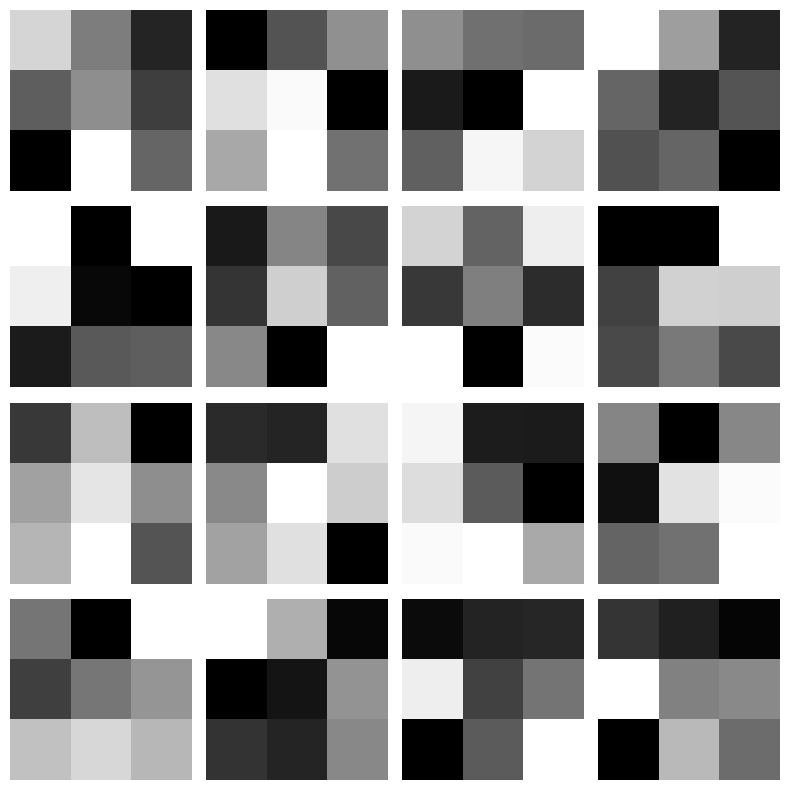

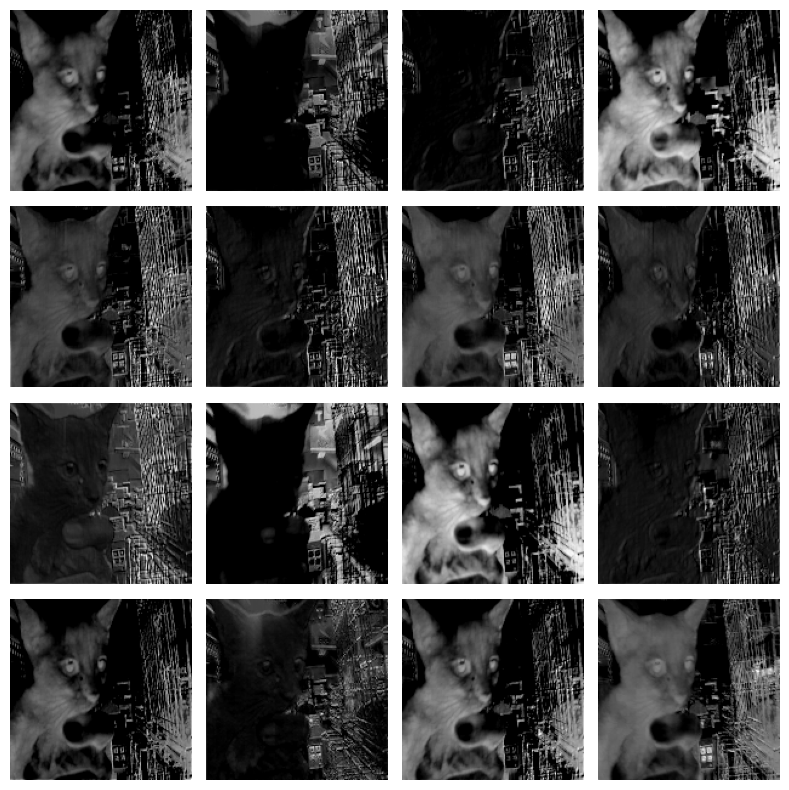

In [7]:
conv1 = cnn_model.features[0]
kernels = conv1.weight.detach().cpu()
kernel_images = kernels.mean(dim=1)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, kernel in zip(axes.flat, kernel_images):
    ax.imshow(kernel, cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

image, _ = test_dataset[0]
with torch.no_grad():
    feature_maps = cnn_model.features[:3](image.unsqueeze(0).to(device)).cpu().squeeze(0)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, fmap in zip(axes.flat, feature_maps):
    ax.imshow(fmap, cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Обратная связь
- [ ] Хочу получить обратную связь по решению